# 05 — Time-Based Analysis
Temporal patterns in foot traffic using frame index as a time proxy.

In [6]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
import seaborn as sns
from scipy.ndimage import gaussian_filter

sns.set_theme(style='whitegrid')

RAW       = Path('../data/raw')
PROCESSED = Path('../data/processed')

## Time metadata check

Before splitting into time windows we need to know whether the dataset carries
real timestamps. Three sources checked:

| Source | Result |
|---|---|
| `mall_gt.mat` keys | `frame`, `count` only — no time field |
| Frame JPEG EXIF | No EXIF data in any frame |
| File modification times | All identical — set at dataset extraction, not recording |

**Conclusion:** no usable time metadata exists. `frame_id` (1–2000) is used as a
monotonic time proxy throughout this notebook.

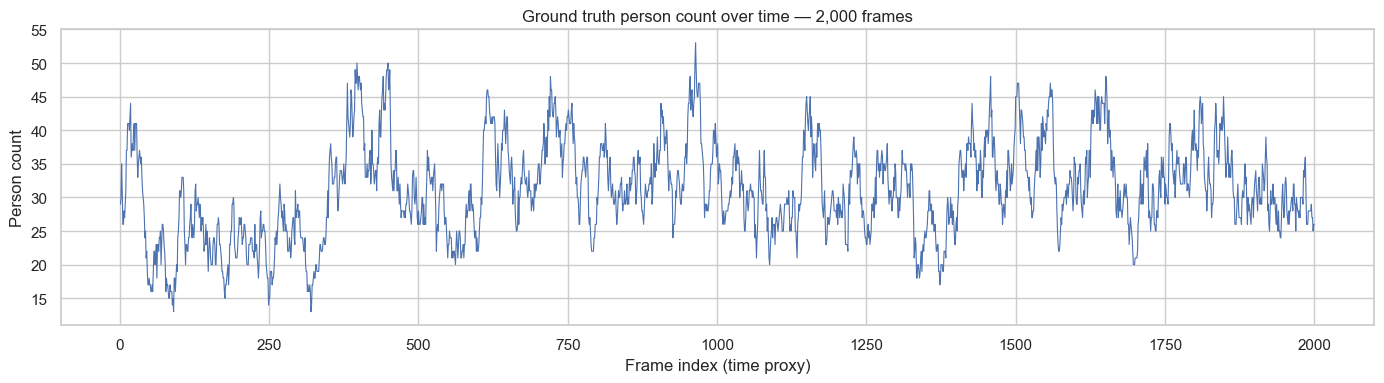

Frames: 1 - 2000
Count range: 13 - 53 persons/frame
Mean: 31.2  Std: 6.9


In [7]:
# Confirm: load gt counts and plot over frame index to visualise the "time" dimension
gt = scipy.io.loadmat(RAW / 'mall_gt.mat')
gt_counts = gt['count'].flatten()  # shape (2000,)

fig, ax = plt.subplots(figsize=(14, 4))
sns.lineplot(x=range(1, len(gt_counts) + 1), y=gt_counts, ax=ax, linewidth=0.8)
ax.set_xlabel('Frame index (time proxy)')
ax.set_ylabel('Person count')
ax.set_title('Ground truth person count over time — 2,000 frames')
plt.tight_layout()
plt.show()

print(f'Frames: 1 - {len(gt_counts)}')
print(f'Count range: {gt_counts.min()} - {gt_counts.max()} persons/frame')
print(f'Mean: {gt_counts.mean():.1f}  Std: {gt_counts.std():.1f}')

## Camera fps & video duration

Provide the camera capture rate. In a production frontend this would be a user input field.

In [8]:
# ── User input ───────────────────────────────────────────────────────────────
CAMERA_FPS = 1  # Hz — replace with actual camera spec

# ── Derived ───────────────────────────────────────────────────────────────────
N_FRAMES    = len(gt_counts)
duration_s  = N_FRAMES / CAMERA_FPS
duration_min = duration_s / 60

print(f'Camera rate:    {CAMERA_FPS} fps')
print(f'Total frames:   {N_FRAMES}')
print(f'Video duration: {duration_min:.1f} min ({duration_s:.0f}s)')

Camera rate:    1 fps
Total frames:   2000
Video duration: 33.3 min (2000s)


## Time window of interest

Specify the analysis window as clock times. Frame 1 is anchored at 11:00 AM.
In a production frontend this would be a time-range picker.

In [9]:
import datetime

# ── Reference anchor ─────────────────────────────────────────────────────────
REFERENCE_TIME = datetime.time(11, 0)  # frame 1 = 11:00 AM

# ── User input ───────────────────────────────────────────────────────────────
WINDOW_START = datetime.time(11, 0)   # start of analysis window
WINDOW_END   = datetime.time(11, 10)  # end   of analysis window

# ── Convert to frame indices ──────────────────────────────────────────────────
def time_to_frame(t, reference, fps):
    ref_dt = datetime.datetime.combine(datetime.date.today(), reference)
    t_dt   = datetime.datetime.combine(datetime.date.today(), t)
    delta_s = (t_dt - ref_dt).total_seconds()
    return max(1, min(N_FRAMES, round(delta_s * fps) + 1))

frame_start = time_to_frame(WINDOW_START, REFERENCE_TIME, CAMERA_FPS)
frame_end   = time_to_frame(WINDOW_END,   REFERENCE_TIME, CAMERA_FPS)

print(f'Reference:    frame 1 = {REFERENCE_TIME.strftime("%H:%M")}'
      f'  →  last frame = {(datetime.datetime.combine(datetime.date.today(), REFERENCE_TIME) + datetime.timedelta(seconds=duration_s)).strftime("%H:%M")}')
print(f'Window:       {WINDOW_START.strftime("%H:%M")} – {WINDOW_END.strftime("%H:%M")}')
print(f'Frame range:  {frame_start} – {frame_end}  ({frame_end - frame_start + 1} frames)')

Reference:    frame 1 = 11:00  →  last frame = 11:33
Window:       11:00 – 11:10
Frame range:  1 – 601  (601 frames)


## Heatmap for selected time window

All frames:    35194 detections
Window frames: 9552 detections  (11:00–11:10, frames 1–601)


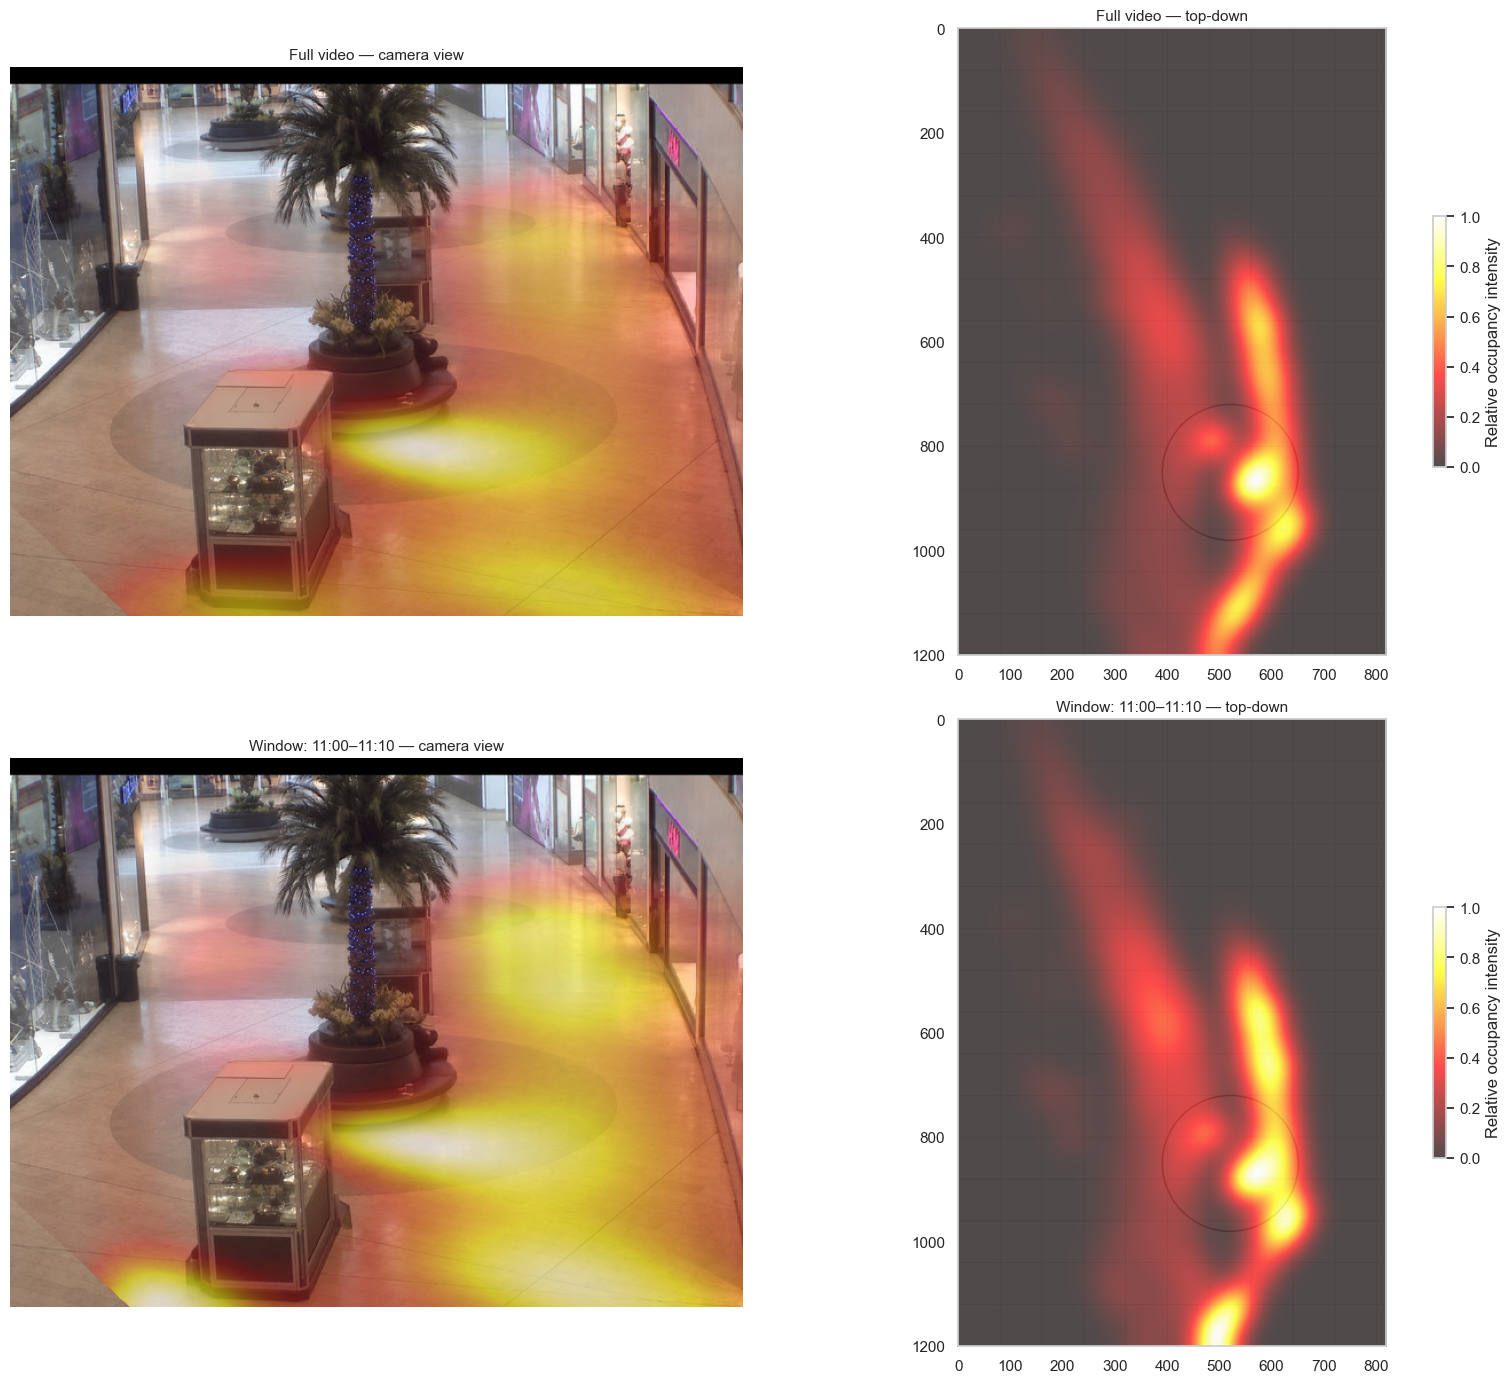

In [11]:
import matplotlib.cm as cm

# Canvas params — must match 03/04 notebooks
FLOOR_W, FLOOR_H = 820, 1200
cx, cy, R = 520, 850, 130
SIGMA = 30
CAM_W, CAM_H = 640, 480

H     = np.load(PROCESSED / 'homography.npy')
H_inv = np.linalg.inv(H)

# Resize reference frame to camera resolution used by homography
_frame85_raw = plt.imread('../reports/figures/Empty_frame_85.jpg')
_frame85_rgb = (_frame85_raw[:, :, :3] * 255).astype(np.uint8) if _frame85_raw.max() <= 1 else _frame85_raw[:, :, :3]
FRAME85 = cv2.resize(_frame85_rgb, (CAM_W, CAM_H))

def make_floor_canvas():
    fp = np.ones((FLOOR_H, FLOOR_W, 3), dtype=np.uint8) * 245
    for x in range(0, FLOOR_W, 80):
        cv2.line(fp, (x, 0), (x, FLOOR_H), (215, 215, 215), 1)
    for y in range(0, FLOOR_H, 80):
        cv2.line(fp, (0, y), (FLOOR_W, y), (215, 215, 215), 1)
    cv2.ellipse(fp, (cx, cy), (R, R), 0, 0, 360, (170, 170, 170), 2)
    return fp

def build_heatmap(df):
    h, _, _ = np.histogram2d(
        df['px'], df['py'],
        bins=[FLOOR_W, FLOOR_H],
        range=[[0, FLOOR_W], [0, FLOOR_H]]
    )
    h = h.T
    h = gaussian_filter(h, sigma=SIGMA)
    return h / h.max() if h.max() > 0 else h

def backproject(heatmap_norm):
    hm_cam  = cv2.warpPerspective(heatmap_norm.astype(np.float32), H_inv, (CAM_W, CAM_H))
    hm_rgba = plt.colormaps['hot'](hm_cam)
    hm_rgb  = (hm_rgba[:, :, :3] * 255).astype(np.uint8)
    alpha   = (0.7 * hm_cam)[:, :, np.newaxis]
    return np.clip((1 - alpha) * FRAME85 + alpha * hm_rgb, 0, 255).astype(np.uint8)

projected = pd.read_csv(PROCESSED / 'projected_detections.csv')
window    = projected[projected['frame_id'].between(frame_start, frame_end)]

heatmap_all    = build_heatmap(projected)
heatmap_window = build_heatmap(window)

print(f'All frames:    {len(projected)} detections')
print(f'Window frames: {len(window)} detections  '
      f'({WINDOW_START.strftime("%H:%M")}–{WINDOW_END.strftime("%H:%M")}, '
      f'frames {frame_start}–{frame_end})')

labels   = ['Full video', f'Window: {WINDOW_START.strftime("%H:%M")}–{WINDOW_END.strftime("%H:%M")}']
heatmaps = [heatmap_all, heatmap_window]

fig, axes = plt.subplots(2, 2, figsize=(16, 14),
                         gridspec_kw={'width_ratios': [CAM_W, FLOOR_W]})

for row, (hm, label) in enumerate(zip(heatmaps, labels)):
    axes[row, 0].imshow(backproject(hm))
    axes[row, 0].grid(False)
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f'{label} — camera view', fontsize=11)

    axes[row, 1].imshow(make_floor_canvas(), extent=[0, FLOOR_W, FLOOR_H, 0])
    im = axes[row, 1].imshow(hm, extent=[0, FLOOR_W, FLOOR_H, 0],
                              cmap='hot', alpha=0.7, vmin=0, vmax=1)
    plt.colorbar(im, ax=axes[row, 1], label='Relative occupancy intensity', shrink=0.4)
    axes[row, 1].grid(False)
    axes[row, 1].set_title(f'{label} — top-down', fontsize=11)

plt.tight_layout()
plt.show()